In [2]:
# Step 1
import sys
sys.path.insert(0, '../..')  # Adjust if needed
import omama as O
import time

In [3]:
# Step 2
omama_loader = O.OmamaLoader()
data = O.Data(data_loader=omama_loader, load_cache=True)

Loading config data from ini file
DataLoader type is:  <class 'omama.loaders.omama_loader.OmamaLoader'>


In [4]:
# Step 3: Loading all 4 images
img1 = O.DataHelper.get(image='DXm.2.25.106924144890407873251702717161766133956')  
img2 = O.DataHelper.get(image='DXm.2.25.109865729760992638360694443409251815567')  
img3 = O.DataHelper.get(image='DXm.2.25.173803440485307451614987519907264671779')  
img4 = O.DataHelper.get(image='DXm.2.25.213465259260888069289877692759291753499')  

In [5]:
img1,img2,img3,img4

(namespace(filePath='/raid/data01/deephealth/dh_dh0new/2.25.151222280059972160195646752408514211111/DXm.2.25.106924144890407873251702717161766133956',
           SOPInstanceUID='2.25.106924144890407873251702717161766133956',
           StudyInstanceUID='2.25.151222280059972160195646752408514211111',
           PatientID='DHTVBOQZ1OMQ',
           InstanceNumber="73",
           label='IndexCancer',
           imageLaterality='L',
           shape=(2457, 1996),
           metadata=Dataset.file_meta -------------------------------
                    (0002, 0000) File Meta Information Group Length  UL: 192
                    (0002, 0001) File Meta Information Version       OB: b'\x00\x01'
                    (0002, 0002) Media Storage SOP Class UID         UI: Digital Mammography X-Ray Image Storage - For Presentation
                    (0002, 0003) Media Storage SOP Instance UID      UI: 2.25.106924144890407873251702717161766133956
                    (0002, 0010) Transfer Syntax UID 

In [7]:
pred = O.DeepSight.run([img1, img2, img3, img4], timing=True)


Time to parse SOP UIDs:  1.1444091796875e-05
Time to check cache:  0.9034664630889893
Running DeepSight on 2 cases, please be patient...
Time to update cache:  3.109502077102661
...took 4.152363300323486


In [8]:
pred

{'2.25.106924144890407873251702717161766133956': {'coords': [324.0,
   1213.0,
   467.0,
   1330.0],
  'score': 0.7945311069488525,
  'errors': None},
 '2.25.173803440485307451614987519907264671779': {'coords': [336.0,
   1224.0,
   486.0,
   1350.0],
  'score': 0.65712571144104,
  'errors': None}}

Showing prediction for 2.25.106924144890407873251702717161766133956
type of data:  <class 'omama.data.Data'>
bb: [324, 1213, 467, 1330]
No prediction for image: 2.25.109865729760992638360694443409251815567
Showing prediction for 2.25.173803440485307451614987519907264671779
type of data:  <class 'omama.data.Data'>
bb: [336, 1224, 486, 1350]
No prediction for image: 2.25.213465259260888069289877692759291753499


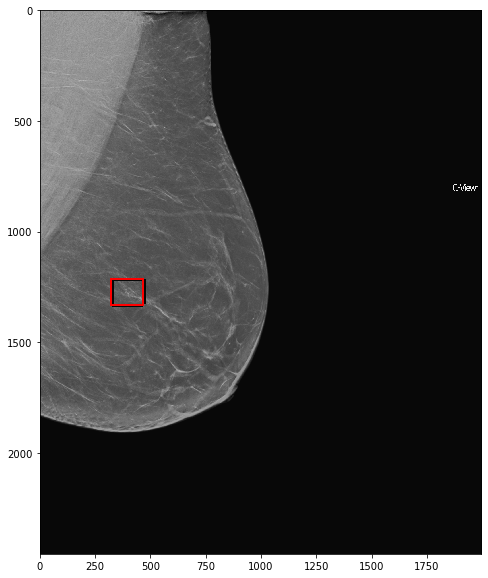

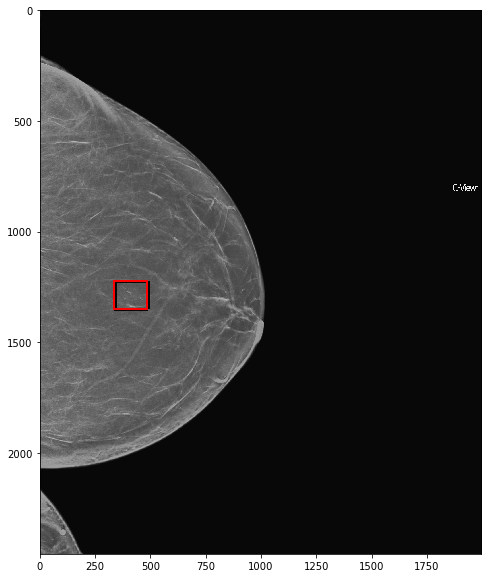

In [10]:
for img in [img1, img2, img3, img4]:
    sop_uid = img.SOPInstanceUID
    if sop_uid in pred:
        print(f"Showing prediction for {sop_uid}")
        O.DataHelper.view(image=img, roi_coords=pred[sop_uid]['coords'])
    else:
        print(f"No prediction for image: {sop_uid}")


In [7]:
print(img2.label)
print(img4.label)


NonCancer
NonCancer
